In [1]:
!pip install python-docx --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


In [3]:
import os
import json
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from docx import Document
from datetime import datetime

# CONFIGURATION

In [4]:
BASE_DIR = "/users/"

COMBINED_DIR = os.path.join(BASE_DIR, "Combined")
CLIENTS_DIR = os.path.join(COMBINED_DIR, "clients_non_iid")
os.makedirs(CLIENTS_DIR, exist_ok=True)

N_CLIENTS = 30
DIRICHLET_ALPHA = 0.3

print("COMBINED_DIR :", COMBINED_DIR)
print("CLIENTS_DIR  :", CLIENTS_DIR)
print("N_CLIENTS    :", N_CLIENTS)
print("ALPHA        :", DIRICHLET_ALPHA)


COMBINED_DIR : /users/
CLIENTS_DIR  : /users/
N_CLIENTS    : 30
ALPHA        : 0.3


In [5]:
train_latent_path = os.path.join(COMBINED_DIR, "combined_train_latent.npy")
y_train_path      = os.path.join(COMBINED_DIR, "combined_y_train.npy")
combined_summary_path = os.path.join(COMBINED_DIR, "combined_summary.json")

assert os.path.exists(train_latent_path), f"Missing: {train_latent_path}"
assert os.path.exists(y_train_path), f"Missing: {y_train_path}"
assert os.path.exists(combined_summary_path), f"Missing: {combined_summary_path}"

X_train = np.load(train_latent_path)
y_train = np.load(y_train_path)

with open(combined_summary_path, "r") as f:
    combined_summary = json.load(f)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Infer classes from labels
unique_labels = sorted(list(set(y_train.tolist())))
num_classes = len(unique_labels)
print("Total distinct class IDs in combined train:", num_classes)
print("Sample class IDs:", unique_labels[:20])
if num_classes > 20:
    print(f"... and {num_classes - 20} more")

X_train shape: (9136746, 64)
y_train shape: (9136746,)
Total distinct class IDs in combined train: 37
Sample class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
... and 17 more


# GLOBAL CLASS DISTRIBUTION (TRAIN - COMBINED)

Global Class Distribution (Combined, encoded IDs):
Class 0 : 4204
Class 1 : 4204
Class 2 : 4203
Class 3 : 4203
Class 4 : 4203
Class 5 : 4204
Class 6 : 4203
Class 7 : 4813839
Class 8 : 22834
Class 9 : 200334
Class 10 : 428
Class 11 : 161
Class 12 : 480208
Class 13 : 1211
Class 14 : 1786
Class 15 : 1803
Class 16 : 403334
Class 17 : 1475
Class 18 : 1474841
Class 19 : 2181
Class 20 : 29055
Class 21 : 323338
Class 22 : 97923
Class 23 : 7693
Class 24 : 135352
Class 25 : 113354
Class 26 : 737
Class 27 : 289739
Class 28 : 166622
Class 29 : 667
Class 30 : 1572
Class 31 : 59722
Class 32 : 50
Class 33 : 339865
Class 34 : 5825
Class 35 : 61
Class 36 : 131312


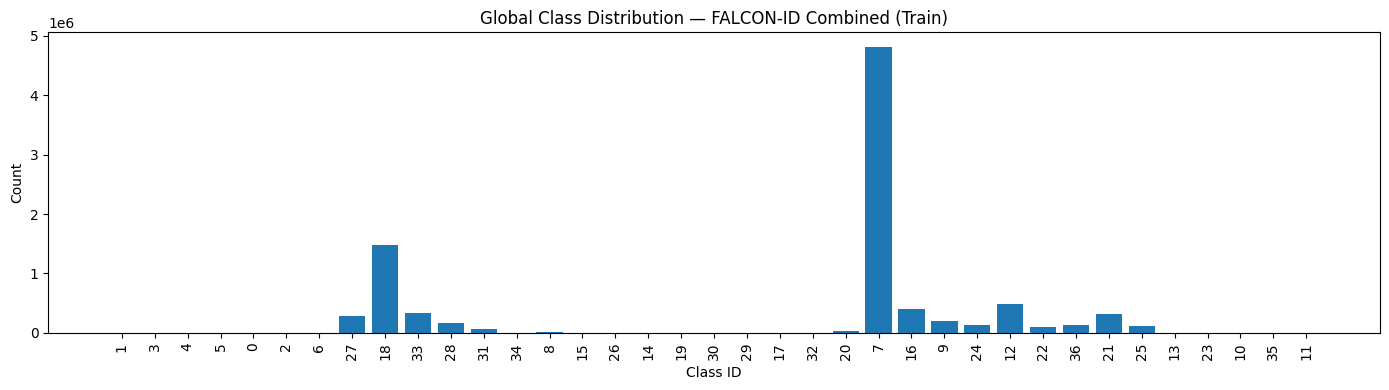

In [6]:
global_counts = Counter(y_train.tolist())

print("Global Class Distribution (Combined, encoded IDs):")
for cls_idx, cnt in sorted(global_counts.items()):
    print(f"Class {cls_idx} : {cnt}")

plt.figure(figsize=(14, 4))
plt.bar(
    [str(k) for k in global_counts.keys()],
    list(global_counts.values())
)
plt.title("Global Class Distribution — FALCON-ID Combined (Train)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Dirichlet Non-IID Partitioning

In [7]:
def dirichlet_partition(y, n_clients, alpha, seed=42):
    np.random.seed(seed)
    random.seed(seed)

    all_indices = np.arange(len(y))
    unique_classes = sorted(list(set(y)))

    class_to_indices = {
        c: all_indices[y == c] for c in unique_classes
    }
    for c in class_to_indices:
        np.random.shuffle(class_to_indices[c])

    client_samples = [[] for _ in range(n_clients)]

    for cls, idxs in class_to_indices.items():
        n = len(idxs)
        if n == 0:
            continue

        # Dirichlet proportions for this class over clients
        proportions = np.random.dirichlet([alpha] * n_clients)

        # Convert to integer counts
        counts = (proportions * n).astype(int)
        diff = n - counts.sum()
        # Fix rounding differences
        for _ in range(diff):
            j = np.random.randint(0, n_clients)
            counts[j] += 1

        start = 0
        for client_id in range(n_clients):
            c_count = counts[client_id]
            if c_count > 0:
                client_samples[client_id].extend(
                    idxs[start:start + c_count]
                )
                start += c_count

    # Shuffle each client's indices
    for cid in range(n_clients):
        arr = np.array(client_samples[cid])
        np.random.shuffle(arr)
        client_samples[cid] = arr

    return client_samples

# PARTITION COMBINED TRAIN DATA INTO NON-IID CLIENTS

In [8]:
client_indices = dirichlet_partition(
    y=y_train,
    n_clients=N_CLIENTS,
    alpha=DIRICHLET_ALPHA,
    seed=42
)

total_assigned = sum(len(idx) for idx in client_indices)
print("Total assigned samples :", total_assigned)
print("Original train samples :", len(y_train))
assert total_assigned == len(y_train), "Mismatch in sample counts!"

Total assigned samples : 9136746
Original train samples : 9136746


# INSPECT CLIENT DISTRIBUTIONS

In [9]:
def class_distribution(indices):
    sub_labels = y_train[indices]
    c = Counter(sub_labels.tolist())
    return {int(k): int(v) for k, v in sorted(c.items())}

client_stats = []

for cid, idxs in enumerate(client_indices):
    dist = class_distribution(idxs)
    num_samples = len(idxs)
    num_classes_in_client = len(dist)

    top3 = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:3]
    top3_readable = [f"{cls_id}:{cnt}" for cls_id, cnt in top3]

    client_stats.append({
        "client_id": cid,
        "num_samples": num_samples,
        "num_classes": num_classes_in_client,
        "class_distribution": dist,
        "top_classes": top3_readable
    })

for s in client_stats:
    print(f"\nClient {s['client_id']}:")
    print("  Samples     :", s["num_samples"])
    print("  #Classes    :", s["num_classes"])
    print("  Top Classes :", ", ".join(s["top_classes"]))


Client 0:
  Samples     : 368960
  #Classes    : 36
  Top Classes : 7:213956, 27:59624, 18:51262

Client 1:
  Samples     : 66907
  #Classes    : 30
  Top Classes : 33:31662, 21:13208, 27:5854

Client 2:
  Samples     : 1583594
  #Classes    : 36
  Top Classes : 7:1325729, 16:81261, 12:53227

Client 3:
  Samples     : 164874
  #Classes    : 33
  Top Classes : 27:42188, 24:28454, 12:25973

Client 4:
  Samples     : 144316
  #Classes    : 32
  Top Classes : 7:104591, 33:19733, 18:9255

Client 5:
  Samples     : 106850
  #Classes    : 33
  Top Classes : 12:43922, 7:36763, 21:16037

Client 6:
  Samples     : 184035
  #Classes    : 32
  Top Classes : 7:105745, 18:39693, 33:15247

Client 7:
  Samples     : 281334
  #Classes    : 29
  Top Classes : 7:105978, 18:45351, 12:39412

Client 8:
  Samples     : 338366
  #Classes    : 33
  Top Classes : 7:104389, 18:101514, 16:64654

Client 9:
  Samples     : 450992
  #Classes    : 31
  Top Classes : 7:245236, 18:136828, 33:20380

Client 10:
  Sample

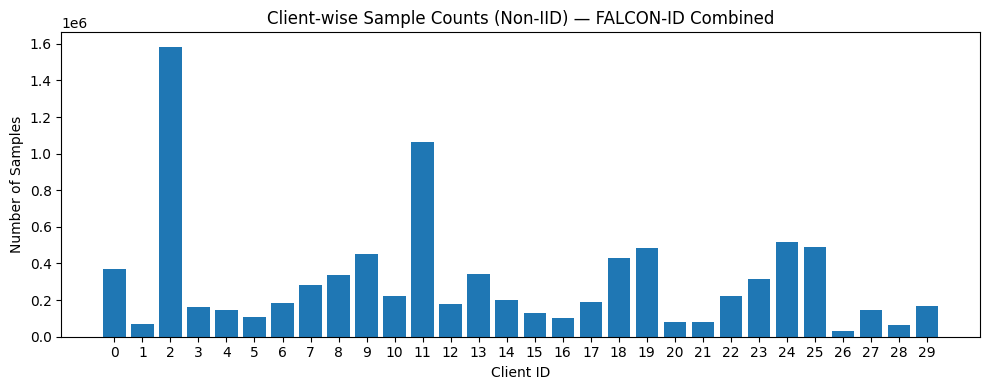

In [10]:
sizes = [s["num_samples"] for s in client_stats]

plt.figure(figsize=(10, 4))
plt.bar(range(N_CLIENTS), sizes)
plt.title("Client-wise Sample Counts (Non-IID) — FALCON-ID Combined")
plt.xlabel("Client ID")
plt.ylabel("Number of Samples")
plt.xticks(range(N_CLIENTS))
plt.tight_layout()
plt.show()

# Save Client Datasets

In [ ]:
for cid, idxs in enumerate(client_indices):
    client_folder = os.path.join(CLIENTS_DIR, f"client_{cid}")
    os.makedirs(client_folder, exist_ok=True)

    Xc = X_train[idxs]
    yc = y_train[idxs]

    np.save(os.path.join(client_folder, "X.npy"), Xc)
    np.save(os.path.join(client_folder, "y.npy"), yc)

print("✔ Saved all client datasets under:", CLIENTS_DIR)

# Save Metadata JSON

In [ ]:
metadata = {
    "dataset_name": "FALCON-ID_Combined",
    "generated_at": datetime.now().isoformat(),
    "n_clients": N_CLIENTS,
    "dirichlet_alpha": DIRICHLET_ALPHA,
    "global": {
        "num_samples": int(len(y_train)),
        "num_classes": int(num_classes),
        "class_ids": [int(c) for c in unique_labels],
        "class_distribution": {int(k): int(v) for k, v in sorted(global_counts.items())},
    },
    "clients": [],
    "source_datasets": list(combined_summary.get("label_maps", {}).keys())
}

for s in client_stats:
    cid = s["client_id"]
    metadata["clients"].append({
        "client_id": cid,
        "num_samples": int(s["num_samples"]),
        "num_classes": int(s["num_classes"]),
        "class_distribution": {int(k): int(v) for k, v in s["class_distribution"].items()},
        "top_classes": s["top_classes"],
    })

meta_path = os.path.join(CLIENTS_DIR, "clients_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("✔ Metadata JSON saved to:", meta_path)

# DOCX Summary Report

In [ ]:
doc = Document()
doc.add_heading("Client Partition Summary — FALCON-ID Combined", level=1)

doc.add_paragraph(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
doc.add_paragraph(f"Number of clients: {N_CLIENTS}")
doc.add_paragraph(f"Dirichlet alpha (Non-IID strength): {DIRICHLET_ALPHA}")
doc.add_paragraph(f"Total train samples: {len(y_train)}")
doc.add_paragraph(f"Distinct class IDs: {num_classes}")

src_ds = metadata.get("source_datasets", [])
if src_ds:
    doc.add_paragraph("Source datasets:")
    for ds_name in src_ds:
        doc.add_paragraph(f"- {ds_name}", style="List Bullet")

doc.add_heading("Global Class Distribution", level=2)
for cls_idx, cnt in sorted(global_counts.items()):
    doc.add_paragraph(
        f"Class {cls_idx}: {cnt}",
        style="List Bullet"
    )

doc.add_heading("Client-wise Summary", level=2)
table = doc.add_table(rows=1, cols=5)
hdr = table.rows[0].cells
hdr[0].text = "Client ID"
hdr[1].text = "#Samples"
hdr[2].text = "#Classes"
hdr[3].text = "Top 3 Classes (ID:count)"
hdr[4].text = "Class Dist (truncated)"

for s in client_stats:
    row = table.add_row().cells
    row[0].text = str(s["client_id"])
    row[1].text = str(s["num_samples"])
    row[2].text = str(s["num_classes"])
    row[3].text = ", ".join(s["top_classes"])

    dist_items = list(s["class_distribution"].items())
    dist_str = ", ".join(
        f"{cls_id}:{cnt}" for cls_id, cnt in dist_items[:5]
    )
    if len(dist_items) > 5:
        dist_str += " ..."
    row[4].text = dist_str

docx_path = os.path.join(CLIENTS_DIR, "clients_metadata_summary.docx")
doc.save(docx_path)

print("✔ DOCX summary saved to:", docx_path)